In [1]:
import matplotlib.pyplot as plt

from phoxipy import PhoXiSensor
import datetime

time = datetime.datetime.now().isoformat()
print("Time: ", time)

p = PhoXiSensor("1703005")
p.start()

frame = p.read()
plt.title("Intensity Image")
plt.imshow(frame.color.data)
plt.tight_layout()
plt.show()
plt.imsave(f"intensity_image{time}.png", frame.color.data)
p.stop()


/home/mallika/anaconda3/envs/lipnew/lib/python3.8/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
ERROR:phoxipy.PhoXiSensor:PhoXi sensor disconnected, check PhoXiControl


Time:  2024-07-02T15:38:30.530469
Reading from PhoXi


SensorIOException: PhoXi sensor not connected

In [ ]:
import PIL.Image as Image
import numpy as np
from decluttering.data.utils.detic_dataloader import DeticDataloader
import matplotlib.pyplot as plt

detic = DeticDataloader()
detic.create()
detic.default_vocab()

Resetting zs_weight datasets/metadata/lvis_v1_clip_a+cname.npy


In [ ]:

# im_frame1 = Image.open('/home/justinyu/multicable-decluttering/decluttering/scripts/test/intensity_image.png')
# im_frame1 = im_frame1.resize((640, 480))
im_frame1 = frame.color.data
np_frame1 = np.array(im_frame1)
d_frame1 = frame.depth.data
np_d_frame1 = np.array(d_frame1)

# remove alpha channel
np_frame1 = np_frame1[0:650, :, :3]

np_d_frame1 = np_d_frame1[0:650, :]

print(np_d_frame1.shape)


(650, 1032)


Inference time:  0.06520223617553711


/home/justinyu/multicable-decluttering/decluttering/data/detectron2_repo/detectron2/structures/image_list.py:99: UserWarning: __floordiv__ is deprecated, and its behavior will change in a future version of pytorch. It currently rounds toward 0 (like the 'trunc' function NOT 'floor'). This results in incorrect rounding for negative values. To keep the current behavior, use torch.div(a, b, rounding_mode='trunc'), or for actual floor division, use torch.div(a, b, rounding_mode='floor').
  max_size = (max_size + (stride - 1)) // stride * stride


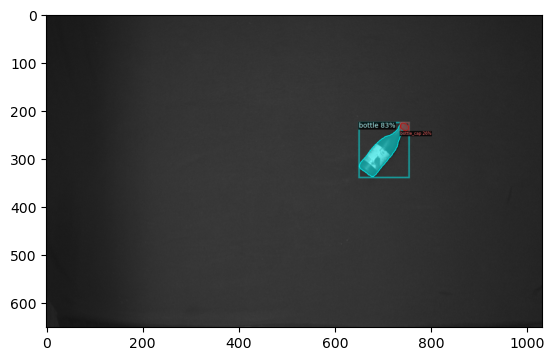

In [ ]:

out = detic.predict(np_frame1)
output_im = out['vis'].get_image()
# print(output_im.shape)
plt.imshow(output_im)
plt.imsave(f"output_image{time}.png", output_im)


Number of masks before filtering torch.Size([2, 1, 650, 1032])
Area of masks before filtering tensor([4281,  226], device='cuda:0')
torch.Size([2, 1, 650, 1032])
Number of masks after filtering:  2
Area of masks after filtering tensor([4281,  226], device='cuda:0')


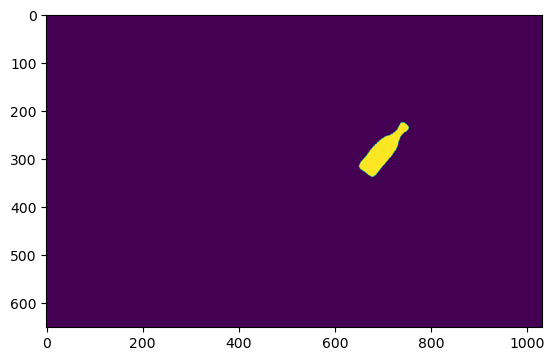

torch.Size([1, 650, 1032])
tensor(4281, device='cuda:0')


In [ ]:
import torch
num_masks = out['masks'].shape[0]
print("Number of masks before filtering", out['masks'].shape)
print("Area of masks before filtering", torch.sum(out['masks'], dim = (1,2,3)))

def filter_mask_by_area(masks, max_area = 400000):
    """
    Filter masks by area
    """
    mask_areas = torch.sum(masks, dim = (1,2,3))
    mask_areas = mask_areas.cpu().numpy()
    mask_areas = mask_areas.reshape(-1)
    masks_filtered = masks[mask_areas < max_area]
    return masks_filtered

def get_largest_mask(masks):
    sorted, indices = torch.sort(torch.sum(masks, dim = (1,2,3)), descending=True)
    return masks[indices[0]]

filtered_areas = filter_mask_by_area(out['masks'])
print(filtered_areas.shape)
num_masks = filtered_areas.shape[0]
print("Number of masks after filtering: ", num_masks)
print("Area of masks after filtering", torch.sum(filtered_areas, dim = (1,2,3)))
# for i in num_masks:
#     plt.imshow(out['masks'][i])
#     plt.show()

plt.imshow(get_largest_mask(filtered_areas).permute((1,2,0)).squeeze(-1).cpu().numpy())
plt.show()

# sorted, indices = torch.sort(torch.sum(filtered_areas, dim = (1,2,3)), descending=True)
# print(indices)

# print(sorted)

# print(torch.sum(filtered_areas, dim = (1,2,3))[indices[0]])
print(get_largest_mask(filtered_areas).shape)
print(torch.sum(get_largest_mask(filtered_areas)))

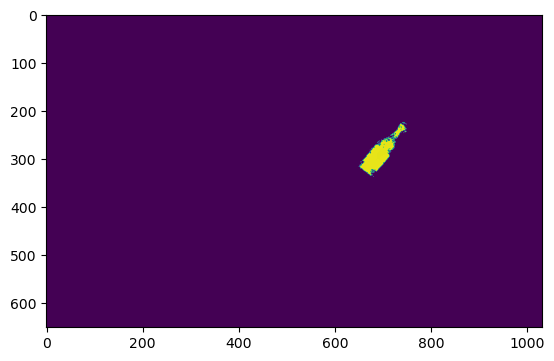

In [ ]:
masked_depth = np_d_frame1 * get_largest_mask(filtered_areas).squeeze(0).cpu().numpy()

# masked_depth.reshape((650, 1032)).shape

plt.imshow(masked_depth)

In [ ]:
import open3d as o3d

In [ ]:
from autolab_core import RigidTransform, PointCloud, RgbdImage, ColorImage, DepthImage


# T_CAM_BASE = RigidTransform.load("/home/justinyu/multicable-decluttering/phoxipy/tools/phoxi_to_world_bww.tf").as_frames(from_frame="phoxi", to_frame="base_link")
#T_CAM_BASE = RigidTransform.load("/nfs/diskstation/calib/phoxi/phoxi_to_world.tf").as_frames(from_frame="phoxi",to_frame="base_link")
intr = PhoXiSensor.create_intr(np_frame1.shape[1], np_frame1.shape[0])
print(intr.K)
# print(frame.depth.frame)
depth = DepthImage(masked_depth, frame.depth.frame)
# print(depth.data[get_largest_mask(filtered_areas).squeeze(0).cpu().numpy()])
# points_3d = intr.deproject(frame.depth)
points_3d = intr.deproject(depth)[get_largest_mask(filtered_areas).squeeze(0).view(-1).cpu().numpy()]

points = np.array(points_3d.data)
points = points.transpose(1,0)

def filter_points(points, threshold = 0.05):
    """
    Filter points by mask
    """
    new_points = []
    # print(points[0][0]**2 +points[0][1]**2 + points[0][2]**2)
    for i in range(points.shape[0]):
        dist_from_origin = points[i][0]**2 +points[i][1]**2 + points[i][2]**2
        # print(dist_from_origin)
        if dist_from_origin > threshold:
            new_points.append(points[i])
    return np.array(new_points)

# print(points_3d.data)
# print(points_3d.data.shape)

points = filter_points(points)
print(points.shape)
# print(points)


[[1.105e+03 0.000e+00 5.160e+02]
 [0.000e+00 1.105e+03 3.250e+02]
 [0.000e+00 0.000e+00 1.000e+00]]
(3095, 3)


In [ ]:
T_CAM_BASE = RigidTransform.load("/home/justinyu/multicable-decluttering/phoxipy/tools/phoxi_to_world_bww.tf").as_frames(from_frame="phoxi", to_frame="base_link")

print(T_CAM_BASE.matrix)

[[ 0.0037658 -0.999983   0.0044605  0.372    ]
 [-0.9938596 -0.0032494  0.1106006 -0.09     ]
 [-0.1105842 -0.0048496 -0.993854   1.045    ]
 [ 0.         0.         0.         1.       ]]


In [ ]:
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(points)
origin = o3d.geometry.TriangleMesh.create_coordinate_frame(size=0.1, origin=[0., 0., 0.])
# Visualize the point cloud
# o3d.visualization.draw_geometries([pcd])
# pcd.voxel_down_sample(voxel_size=0.05)

# pcd.estimate_normals(
#     search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=0.1, max_nn=30))
# Visualize normals
# o3d.visualization.draw_geometries([pcd], point_show_normal=True)
aabb = pcd.get_axis_aligned_bounding_box()
# aabb = pcd.get_oriented_bounding_box()
aabb.color = (1, 0, 0)
o3d.visualization.draw_geometries([pcd, aabb, origin])

print(np.asarray(aabb.get_box_points()))
print(aabb.get_center())
bbox_3d = np.asarray(aabb.get_box_points())

center_3d = aabb.get_center()

center_3d_homog = np.array([center_3d[0], center_3d[1], center_3d[2], 1])

robot_frame_object_center = T_CAM_BASE.matrix @ center_3d_homog
print(robot_frame_object_center)


[[ 0.11847069 -0.08917805  0.95455021]
 [ 0.20746406 -0.08917805  0.95455021]
 [ 0.11847069  0.01073302  0.95455021]
 [ 0.11847069 -0.08917805  0.9962033 ]
 [ 0.20746406  0.01073302  0.9962033 ]
 [ 0.11847069  0.01073302  0.9962033 ]
 [ 0.20746406 -0.08917805  0.9962033 ]
 [ 0.20746406  0.01073302  0.95455021]]
[ 0.16296737 -0.03922252  0.97537675]
[ 0.41618622 -0.14396198  0.05778651  1.        ]


The oriented bounding box is: ((705.0491333007812, 277.5409851074219), (41.996097564697266, 132.39013671875), 39.80556869506836)


/tmp/ipykernel_262671/3406499620.py:42: DeprecationWarning: `np.int0` is a deprecated alias for `np.intp`.  (Deprecated NumPy 1.24)
  box = np.int0(box)


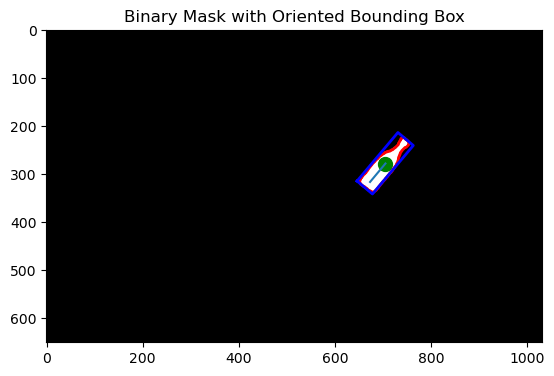

[705.0491333  277.54098511]
-0.6401843675228864
0.768221306382036


In [ ]:
import cv2
import numpy as np

def get_oriented_bounding_box(binary_mask):
    """
    Fit the tightest oriented bounding box around a 2D binary mask.
    
    Parameters:
    binary_mask (numpy.ndarray): A 2D numpy array representing the binary mask image.
    
    Returns:
    tuple: The (center (x, y), (width, height), angle of rotation) of the bounding box.
    """
    # Ensure the input is a binary mask
    binary_mask = np.asarray(binary_mask, dtype=np.uint8)
    
    # Find contours in the binary mask
    contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Get the largest contour, assuming the mask is connected
    largest_contour = max(contours, key=cv2.contourArea)
    
    # Get the minimum area bounding rectangle
    rect = cv2.minAreaRect(largest_contour)
    
    return rect, largest_contour


rect, contour = get_oriented_bounding_box(get_largest_mask(filtered_areas).permute((1,2,0)).squeeze(-1).cpu().numpy())
print(f"The oriented bounding box is: {rect}")

def plot_mask_with_bbox(binary_mask, rect, contour):
    """
    Plot the binary mask with the oriented bounding box.
    
    Parameters:
    binary_mask (numpy.ndarray): A 2D numpy array representing the binary mask image.
    rect (tuple): The (center (x, y), (width, height), angle of rotation) of the bounding box.
    contour (numpy.ndarray): Contour of the largest component in the binary mask.
    """
    box = cv2.boxPoints(rect)
    box = np.int0(box)

    angle = rect[2]
    if rect[1][0] > rect[1][1]:
        angle = angle + 90
    
    plt.figure()
    plt.imshow(binary_mask, cmap='gray')
    plt.plot(contour[:, 0, 0], contour[:, 0, 1], 'r', linewidth=2)
    plt.plot(*zip(*np.vstack([box, box[0]])), 'b-', linewidth=2)
    plt.scatter(rect[0][0], rect[0][1], color='green', s=100)
    plt.plot([rect[0][0], rect[0][0]-50*np.sin(np.radians(angle))], [rect[0][1], rect[0][1]+50*np.cos(np.radians(angle))])
    plt.title("Binary Mask with Oriented Bounding Box")
    plt.show()

plot_mask_with_bbox(get_largest_mask(filtered_areas).permute((1,2,0)).squeeze(-1).cpu().numpy(), rect, contour)

# print(np.array(rect[0]).transpose())
center = np.array(rect[0])
angle = rect[2]
if rect[1][0] > rect[1][1]:
    angle = angle + 90

print(center)
print(-np.sin(np.radians(angle)))
print(np.cos(np.radians(angle)))


In [ ]:
from decluttering.deprecated.push_through_backup2 import perform_point_grasp, drop_in_bin, get_gripper_rot, get_world_coord_from_pixel_coord
from decluttering.deprecated.demopipeline import DemoPipeline
from untangling.utils.tcps import *

def initialize_pipeline(logLevel):
    pipeline = DemoPipeline(viz=False, loglevel=logLevel, initialize_iface=True)
    pipeline.iface.open_grippers()
    pipeline.iface.sync()
    pipeline.iface.home()
    pipeline.iface.sync()
    return pipeline

pipeline = initialize_pipeline('DEBUG')
pipeline.iface.home()
pipeline.iface.sync()
pipeline.iface.open_grippers()
pipeline.iface.sync()

robot_frame_object_center

# waypoint1 = np.array([center[0], center[1]])
iface = pipeline.iface

# print(waypoint1)
# iface.open_grippers()
# iface.sync()
# if waypoint1[0] > 550:
print("Using right arm")
place1_ui_world = get_world_coord_from_pixel_coord(center, iface.cam.intrinsics) # convert pixel coordinates to 3d coordinates
print("(u,v) to world coord", place1_ui_world)
# place2 = get_world_coord_from_pixel_coord(waypoint2, iface.cam.intrinsics) # convert pixel coordinates to 3d coordinates
place1 = [place1_ui_world[0], place1_ui_world[1], place1_ui_world[2]]
print("depth to world coord", place1)
intermediate_place1 = [place1[0], place1[1], place1[2]+0.1]
rot = get_gripper_rot(angle, iface)
intermediate_place1_transform = RigidTransform(
    translation=intermediate_place1,
    rotation=rot,
    from_frame=YK.r_tcp_frame,
    to_frame="base_link",
)
place1_transform = RigidTransform(
    translation=place1,
    rotation=rot,
    from_frame=YK.r_tcp_frame,
    to_frame="base_link",
)
good_path = iface.check_cartesian_path(r_targets=[intermediate_place1_transform, place1_transform, intermediate_place1_transform], removejumps=[6])
if not good_path:
    raise Exception("Unable to plan jump-free cartesian path despite numerous attempts.")

iface.go_cartesian(r_targets=[intermediate_place1_transform, place1_transform], removejumps=[6])
iface.sync()
time.sleep(1.5)


Directory 'logs_2024-06-28_21-03-33' created
./logs/full_rollouts/logs_2024-06-28_21-03-33


/home/mallika/anaconda3/envs/lipnew/lib/python3.8/site-packages/torch/nn/modules/lazy.py:178: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '


move joints
move joints
Using right arm
(u,v) to world coord [ 0.47525606 -0.14911512  0.0575    ]
depth to world coord [0.4752560586565692, -0.14911511880513045, 0.0575]
Jump of magnitude 6.228045974582461 found in joint 6
Jump of magnitude 6.228045987545297 found in joint 6


AttributeError: 'str' object has no attribute 'sleep'

In [ ]:
print(iface.GRIP_DOWN_R)
print(iface.GRIP_DOWN_L)

[[ 1  0  0]
 [ 0 -1  0]
 [ 0  0 -1]]


AttributeError: 'Interface' object has no attribute 'GRIP_DOWN_L'

In [ ]:

# iface.close_gripper('right')
# iface.sync()
# time.sleep(1)

# iface.go_cartesian(r_targets=[intermediate_place1_transform], removejumps=[6])
# iface.sync()
# time.sleep(1)



# time.sleep(1)
# iface.home()
# iface.sync()
# time.sleep(1)

In [ ]:
# from decluttering.deprecated.push_through_backup2 import get_poi_and_vec_for_push, perform_push_through, perform_pindown, perform_pick_away, perform_point_grasp, drop_in_bin
# from decluttering.deprecated.demopipeline import DemoPipeline

# def initialize_pipeline(logLevel):
#     pipeline = DemoPipeline(viz=False, loglevel=logLevel, initialize_iface=True)
#     pipeline.iface.open_grippers()
#     pipeline.iface.sync()
#     pipeline.iface.home()
#     pipeline.iface.sync()
#     return pipeline

# pipeline = initialize_pipeline('DEBUG')
# pipeline.iface.home()
# pipeline.iface.sync()
# pipeline.iface.open_grippers()
# pipeline.iface.sync()

# print("Angle is: ", angle)
# print(center)
# perform_point_grasp(center, np.radians(angle), pipeline)

# pipeline.iface.home()
# pipeline.iface.sync()

Directory 'logs_2024-06-25_21-35-27' created
./logs/full_rollouts/logs_2024-06-25_21-35-27


/home/mallika/anaconda3/envs/lipnew/lib/python3.8/site-packages/torch/nn/modules/lazy.py:178: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '


move joints
move joints
Angle is:  135.0
[312.75003052 179.25      ]
[312.75003052 179.25      ]
Using left arm
[0.5567066111471737, 0.22238891910229158, 0.0635]
move joints
move joints


RuntimeError: Timeout during sync